# Preparatory Study for the PhD Project

**Target project:** *Causal AI and EEG Analysis to Characterise Sleep in Children with Neurodevelopmental Conditions*

To prepare for this PhD project, I conducted a preliminary study using a publicly available paediatric sleep-EEG dataset. The aim was to familiarise myself with the data structure, explore sleep-related EEG patterns, and investigate where causal AI may be useful.

## 1. Understanding the Data

I first inspected the recording structure and the available sleep-stage annotations.

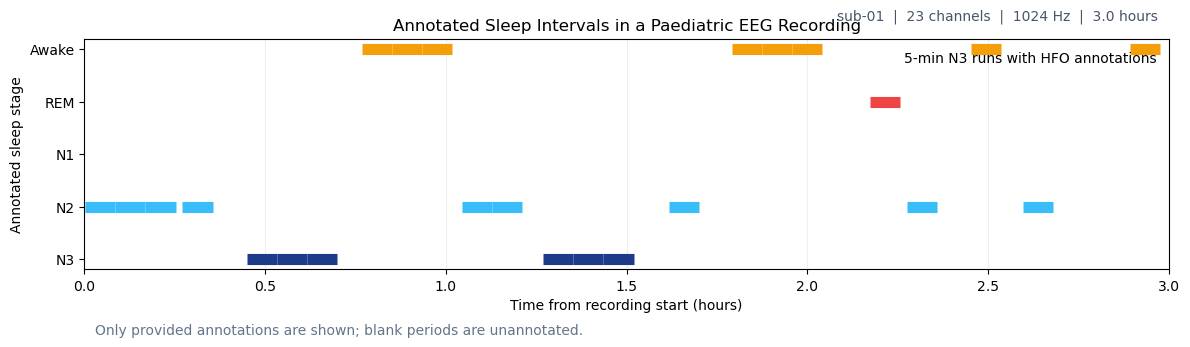

In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import mne
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

mne.set_log_level("ERROR")

ROOT = Path(r"D:\Coding\ds003555")
RAW_EDF = ROOT / "sub-01/ses-01/eeg/sub-01_ses-01_task-hfo_eeg.edf"
DERIV_DIR = ROOT / "derivatives/sub-01/ses-01/eeg"

raw = mne.io.read_raw_edf(RAW_EDF, preload=False, verbose=False)
intervals = pd.read_csv(DERIV_DIR / "DataIntervals.tsv", sep="\t")

sfreq = float(raw.info["sfreq"])
duration_hours = raw.n_times / sfreq / 3600

stage_order = ["Awake", "REM", "N1", "N2", "N3"]
stage_y = {stage: i for i, stage in enumerate(stage_order[::-1])}
stage_colors = {
    "Awake": "#f59e0b",
    "REM": "#ef4444",
    "N1": "#86efac",
    "N2": "#38bdf8",
    "N3": "#1e3a8a",
}

fig, ax = plt.subplots(figsize=(12, 3.8))

for _, row in intervals.iterrows():
    stage = row["SleepStage"]
    if stage not in stage_y:
        continue

    start_h = row["StartInd"] / sfreq / 3600
    stop_h = row["EndInd"] / sfreq / 3600

    ax.plot(
        [start_h, stop_h],
        [stage_y[stage]] * 2,
        color=stage_colors[stage],
        linewidth=8,
        solid_capstyle="butt",
    )

n3_runs = intervals.loc[pd.to_numeric(intervals["RunNb"], errors="coerce").gt(0)]
run_midpoints = (
    n3_runs["StartInd"] + n3_runs["EndInd"]
) / (2 * sfreq * 3600)

ax.scatter(
    run_midpoints,
    [stage_y["N3"]] * len(run_midpoints),
    marker="|",
    s=150,
    color="white",
    linewidth=1.5,
    label="5-min N3 runs with HFO annotations",
)

ax.set(
    xlim=(0, duration_hours),
    yticks=list(stage_y.values()),
    yticklabels=list(stage_y.keys()),
    xlabel="Time from recording start (hours)",
    ylabel="Annotated sleep stage",
    title="Annotated Sleep Intervals in a Paediatric EEG Recording",
)

ax.text(
    0.99, 1.08,
    f"sub-01  |  {len(raw.ch_names)} channels  |  "
    f"{sfreq:.0f} Hz  |  {duration_hours:.1f} hours",
    transform=ax.transAxes,
    ha="right",
    color="#475569",
)

ax.text(
    0.01, -0.28,
    "Only provided annotations are shown; blank periods are unannotated.",
    transform=ax.transAxes,
    color="#64748b",
    fontsize=10,
)

ax.grid(axis="x", alpha=0.2)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

The dataset contains approximately three hours of paediatric sleep EEG. Sleep labels are only available for selected intervals. HFO annotations are provided for selected five-minute N3 intervals, which therefore form the main unit of the subsequent analysis.

### 1.1 Sleep Physiology and HFO Annotations

I then examined whether the annotated sleep stages showed the expected spectral structure and how the provided High-frequency oscillation (HFO) annotations appeared in the original EEG.

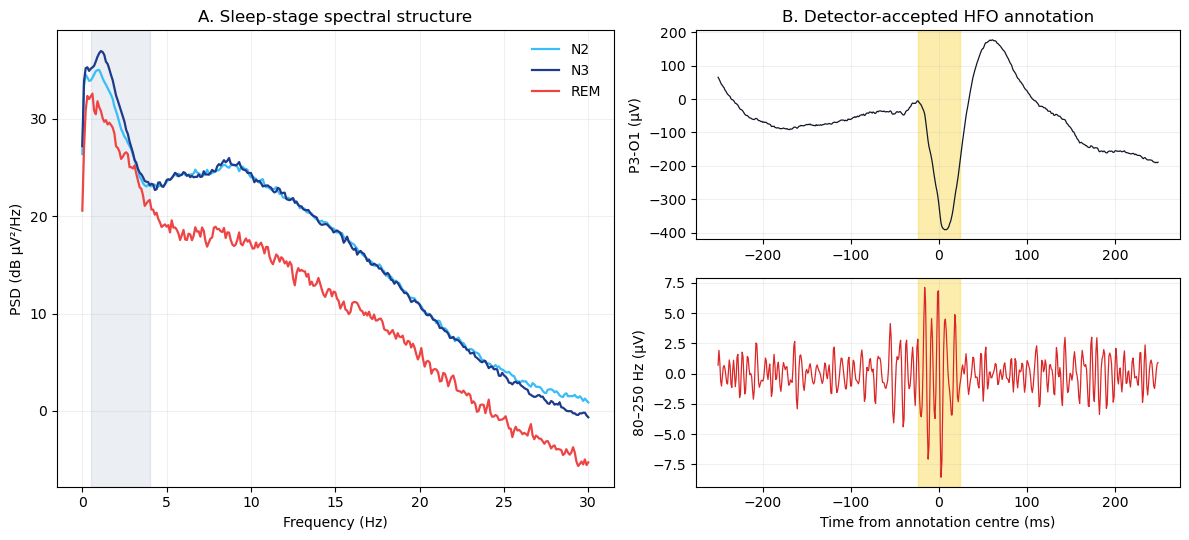

In [8]:
from scipy.signal import welch, butter, sosfiltfilt

# Stage-specific PSD using consistent bipolar references
stages = ["N2", "N3", "REM"]
colors = {"N2": "#38bdf8", "N3": "#1e3a8a", "REM": "#ef4444"}
stage_psd = {}
nperseg = int(10 * sfreq)

for stage in stages:
    psds = []

    for _, row in intervals.loc[intervals["SleepStage"].eq(stage)].iterrows():
        data = raw.get_data(
            picks=["C3", "A2", "C4", "A1"],
            start=int(row["StartInd"]),
            stop=int(row["EndInd"]),
        )
        bipolar = np.vstack([data[0] - data[1], data[2] - data[3]])

        freqs, pxx = welch(
            bipolar, fs=sfreq, window="hann",
            nperseg=nperseg, noverlap=nperseg // 2,
            detrend="constant", scaling="density", axis=-1,
        )
        psds.append(pxx.mean(axis=0))

    stage_psd[stage] = np.mean(psds, axis=0)

# Map one detector-accepted HFO back to the original recording
events = pd.read_csv(
    DERIV_DIR / "sub-01_ses-01_task-hfo_run-01_events.tsv",
    sep="\t",
)
deriv_channels = pd.read_csv(
    DERIV_DIR / "sub-01_ses-01_task-hfo_run-01_channels.tsv",
    sep="\t",
)
deriv_sfreq = float(
    deriv_channels.loc[
        deriv_channels["name"].eq("P3-O1"),
        "sampling_frequency",
    ].iloc[0]
)

accepted = events.loc[
    pd.to_numeric(events["EvPassRejection"], errors="coerce").eq(1)
    & events["strChannelName"].eq("P3-O1")
].copy()

accepted["onset_s"] = accepted["indStart"] / deriv_sfreq
accepted["offset_s"] = accepted["indStop"] / deriv_sfreq
hfo = accepted.iloc[0]

run1 = intervals.loc[pd.to_numeric(intervals["RunNb"]).eq(1)].iloc[0]
run_data = raw.get_data(
    picks=["P3", "O1"],
    start=int(run1["StartInd"]),
    stop=int(run1["EndInd"]),
)
p3_o1 = run_data[0] - run_data[1]

sos = butter(4, [80, 250], btype="bandpass", fs=sfreq, output="sos")
hfo_band = sosfiltfilt(sos, p3_o1)

center_s = (hfo["onset_s"] + hfo["offset_s"]) / 2
half_window = 0.25
start = int((center_s - half_window) * sfreq)
stop = int((center_s + half_window) * sfreq)
time_ms = (np.arange(start, stop) / sfreq - center_s) * 1000

onset_ms = (hfo["onset_s"] - center_s) * 1000
offset_ms = (hfo["offset_s"] - center_s) * 1000

fig, axes = plt.subplot_mosaic(
    [["psd", "raw"], ["psd", "hfo"]],
    figsize=(12, 5.5),
    gridspec_kw={"width_ratios": [1.15, 1]},
)

mask = freqs <= 30
for stage in stages:
    axes["psd"].plot(
        freqs[mask],
        10 * np.log10(stage_psd[stage][mask]),
        label=stage,
        color=colors[stage],
        linewidth=1.6,
    )

axes["psd"].axvspan(0.5, 4, color="#94a3b8", alpha=0.18)
axes["psd"].set(
    xlabel="Frequency (Hz)",
    ylabel="PSD (dB µV²/Hz)",
    title="A. Sleep-stage spectral structure",
)
axes["psd"].legend(frameon=False)

axes["raw"].plot(time_ms, p3_o1[start:stop], color="#111827", linewidth=0.9)
axes["hfo"].plot(time_ms, hfo_band[start:stop], color="#dc2626", linewidth=0.9)

for key in ["raw", "hfo"]:
    axes[key].axvspan(onset_ms, offset_ms, color="#facc15", alpha=0.35)
    axes[key].grid(alpha=0.18)

axes["raw"].set(
    ylabel="P3-O1 (µV)",
    title="B. Detector-accepted HFO annotation",
)
axes["hfo"].set(
    xlabel="Time from annotation centre (ms)",
    ylabel="80–250 Hz (µV)",
)

for ax in axes.values():
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

The annotated stages showed distinct spectral structure, with stronger low-frequency activity during N3 than REM. The HFO annotations were provided by the dataset.

## 2. Are HFO Annotations Temporally Independent?

The dataset represents channel-wise HFO detections as individual events. A simple downstream analysis may therefore implicitly treat these annotations as independent observations. I examined whether the accepted HFOs were instead temporally clustered across channels.

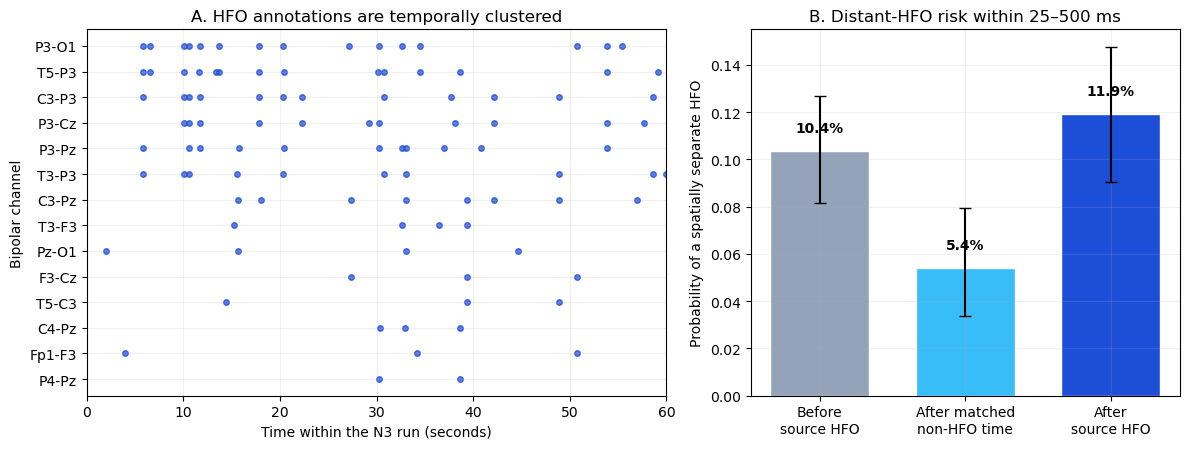

In [13]:
# Panel A: channel-wise HFO raster from the first 60 seconds
all_hfo = events.loc[
    pd.to_numeric(events["EvPassRejection"], errors="coerce").eq(1)
].copy()

all_hfo["time_s"] = (
    pd.to_numeric(all_hfo["indStart"], errors="coerce")
    / deriv_sfreq
)
all_hfo = all_hfo.loc[all_hfo["time_s"].between(0, 60)]

channel_order = (
    all_hfo["strChannelName"]
    .value_counts()
    .head(14)
    .index[::-1]
)

# Panel B: short-lag risk from the merged-burst event study
event_study = pd.read_csv(ROOT / "hfo_burst_event_study_v1.csv")

risk_columns = [
    "source_pre_outcome",
    "control_post_outcome",
    "exposed_post_outcome",
]
labels = [
    "Before\nsource HFO",
    "After matched\nnon-HFO time",
    "After\nsource HFO",
]
participant_risks = (
    event_study
    .groupby("participant_id")[risk_columns]
    .mean()
)

risks = participant_risks.mean().to_numpy()

rng = np.random.default_rng(42)
risk_array = participant_risks.to_numpy()
n_participants = len(risk_array)

bootstrap_risks = np.asarray([
    risk_array[
        rng.integers(0, n_participants, n_participants)
    ].mean(axis=0)
    for _ in range(3000)
])

ci_low, ci_high = np.percentile(
    bootstrap_risks,
    [2.5, 97.5],
    axis=0,
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.6),
    gridspec_kw={"width_ratios": [1.35, 1]},
)

for y, channel in enumerate(channel_order):
    times = all_hfo.loc[
        all_hfo["strChannelName"].eq(channel),
        "time_s",
    ]
    axes[0].scatter(
        times,
        np.full(len(times), y),
        s=16,
        color="#1d4ed8",
        alpha=0.75,
    )

axes[0].set(
    xlim=(0, 60),
    yticks=np.arange(len(channel_order)),
    yticklabels=channel_order,
    xlabel="Time within the N3 run (seconds)",
    ylabel="Bipolar channel",
    title="A. HFO annotations are temporally clustered",
)

x = np.arange(3)
axes[1].bar(
    x,
    risks,
    width=0.68,
    color=["#94a3b8", "#38bdf8", "#1d4ed8"],
    yerr=[risks - ci_low, ci_high - risks],
    capsize=4,
    edgecolor="white",
)

for i, value in enumerate(risks):
    axes[1].text(
        i, value + 0.008,
        f"{100 * value:.1f}%",
        ha="center",
        weight="bold",
    )

axes[1].set(
    xticks=x,
    xticklabels=labels,
    ylabel="Probability of a spatially separate HFO",
    title="B. Distant-HFO risk within 25–500 ms",
)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

**Non-random Temporal Structure and Possible Directionality**

The event raster suggested that HFO annotations were not uniformly isolated in time. After merging near-synchronous detections and excluding channels that shared an electrode with the source, spatially separate HFOs remained more frequent around real source events than around matched non-HFO times.

However, the increased risk appeared both before and after the source HFO. This temporal clustering could reflect a transient common brain state rather than transmission from one HFO to another. A causal interpretation therefore requires a directional analysis that can distinguish propagation from background excitability and temporal confounding.

## 3. From Temporal Clustering to a Causal Question

Intracranial EEG studies have reported repetitive, millisecond-scale HFO sequences across cortical sites, suggesting that HFOs may participate in epileptic network dynamics and propagation ([Jahromi et al., 2024](https://pubmed.ncbi.nlm.nih.gov/38746136/)).

This provides a plausible neuroscientific explanation for the clustering observed in this dataset. However, the same pattern could also arise if a transient HFO-rich brain state independently increased both source and subsequent HFO activity.

**Research question:** After accounting for preceding HFO activity and recording context, does a source HFO increase the short-lag probability of a spatially non-overlapping HFO?

**Why causal AI?** A predictive association cannot distinguish directional propagation from shared background excitability. Causal modelling provides an explicit estimand, adjustment strategy and falsification framework.

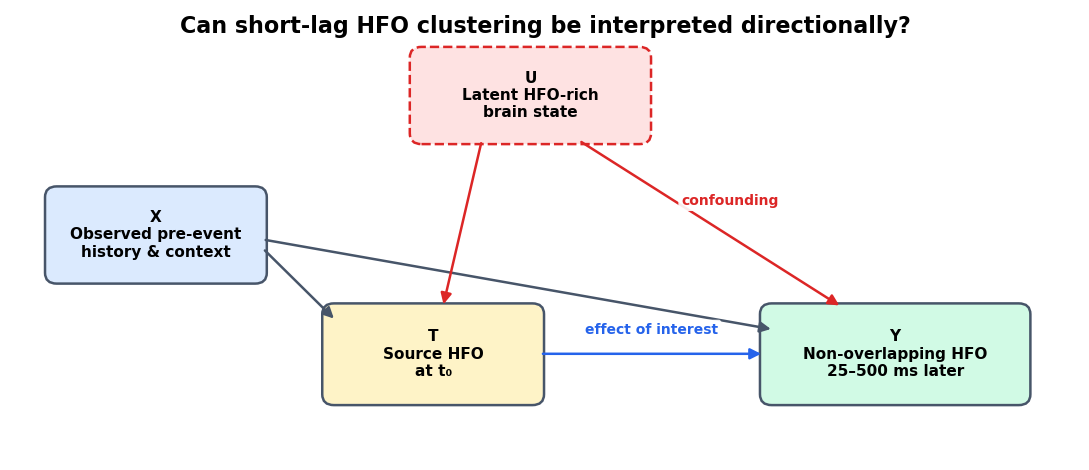

In [14]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis("off")

def node(x, y, w, h, text, facecolor, edgecolor="#475569", linestyle="-"):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=1.8,
        linestyle=linestyle,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=11, weight="bold",
    )

def arrow(start, end, color="#475569", label=None, offset=(0, 0)):
    patch = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.8,
        color=color,
        connectionstyle="arc3,rad=0.0",
    )
    ax.add_patch(patch)

    if label:
        midpoint = (
            (start[0] + end[0]) / 2 + offset[0],
            (start[1] + end[1]) / 2 + offset[1],
        )
        ax.text(
            *midpoint, label,
            ha="center", va="center",
            color=color, fontsize=10, weight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.9,
            ),
        )

node(
    0.4, 2.0, 2.2, 1.0,
    "X\nObserved pre-event\nhistory & context",
    "#dbeafe",
)
node(
    4.15, 3.55, 2.4, 1.0,
    "U\nLatent HFO-rich\nbrain state",
    "#fee2e2",
    edgecolor="#dc2626",
    linestyle="--",
)
node(
    3.25, 0.65, 2.2, 1.05,
    "T\nSource HFO\nat t₀",
    "#fef3c7",
)
node(
    7.75, 0.65, 2.7, 1.05,
    "Y\nNon-overlapping HFO\n25–500 ms later",
    "#d1fae5",
)

arrow((2.6, 2.35), (3.35, 1.55))
arrow((2.6, 2.45), (7.85, 1.45))
arrow((4.85, 3.55), (4.45, 1.7), color="#dc2626")
arrow((5.85, 3.55), (8.55, 1.7), color="#dc2626", label="confounding", offset=(0.2, 0.25))
arrow(
    (5.45, 1.18), (7.75, 1.18),
    color="#2563eb",
    label="effect of interest",
    offset=(0, 0.27),
)

ax.text(
    5.5, 4.82,
    "Can short-lag HFO clustering be interpreted directionally?",
    ha="center", va="center",
    fontsize=16, weight="bold",
)

plt.tight_layout()
plt.show()

- **Exposure (T):** an isolated source HFO detected on one bipolar channel.
- **Outcome (Y):** at least one HFO on a non-overlapping bipolar channel 25–500 ms later.
- **Comparison (T = 0):** a matched non-HFO time from the same N3 run.
- **Estimand:** the average risk difference in the subsequent non-overlapping HFO outcome.

The target pathway is \(T → Y\). Observed pre-event history and recording context \(X\) can be adjusted for, whereas latent brain state \(U\) remains a potential source of unmeasured confounding.

## 4. Causal Design

Each source-HFO time was paired with a non-HFO time from the same participant, N3 run and source channel. Only information occurring before the reference time was used for adjustment.

Participant-grouped cross-fitting prevented information from the same child appearing in both training and test folds. LightGBM estimated the exposure and outcome models, which were combined using augmented inverse-probability weighting (AIPW).

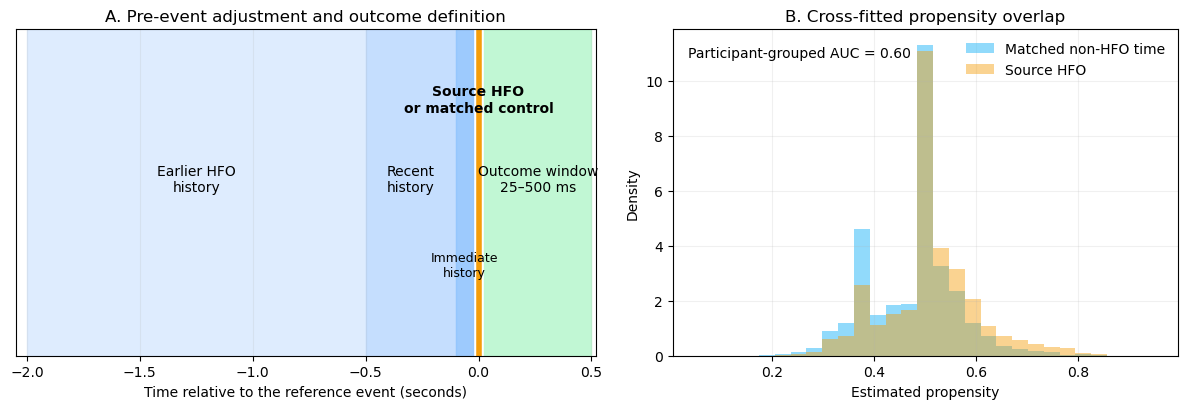

In [15]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

causal_samples = pd.read_csv(
    ROOT / "hfo_propagation_causal_samples_v1.csv"
)

numeric_features = [
    "run",
    "time_fraction",
    "age",
    "sex_binary",
    "history_25_100ms",
    "history_100_500ms",
    "history_500ms_2s",
    "history_2_10s",
    "source_channel_history_10s",
    "active_channels_history_2s",
    "distant_HFO_before",
]

channel_features = pd.get_dummies(
    causal_samples["source_channel"],
    prefix="source",
    dtype=float,
)

X = np.column_stack([
    causal_samples[numeric_features].to_numpy(dtype=float),
    channel_features.to_numpy(dtype=float),
])
T = causal_samples["treatment"].to_numpy(dtype=int)
Y = causal_samples["outcome"].to_numpy(dtype=int)
groups = causal_samples["participant_id"].to_numpy()

def make_model(seed):
    return LGBMClassifier(
        objective="binary",
        n_estimators=250,
        learning_rate=0.025,
        max_depth=3,
        num_leaves=15,
        min_child_samples=30,
        reg_alpha=0.1,
        reg_lambda=1.0,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=seed,
        verbosity=-1,
        n_jobs=-1,
    )

propensity = np.full(len(Y), np.nan)
mu1 = np.full(len(Y), np.nan)
mu0 = np.full(len(Y), np.nan)

SEED = 42

for fold, (train, test) in enumerate(
    GroupKFold(n_splits=5).split(X, Y, groups),
    start=1,
):
    propensity_model = make_model(SEED + fold)
    propensity_model.fit(X[train], T[train])
    propensity[test] = propensity_model.predict_proba(X[test])[:, 1]

    treated_train = train[T[train] == 1]
    control_train = train[T[train] == 0]

    treated_model = make_model(SEED + 100 + fold)
    control_model = make_model(SEED + 200 + fold)

    treated_model.fit(X[treated_train], Y[treated_train])
    control_model.fit(X[control_train], Y[control_train])

    mu1[test] = treated_model.predict_proba(X[test])[:, 1]
    mu0[test] = control_model.predict_proba(X[test])[:, 1]

propensity = np.clip(propensity, 0.05, 0.95)

aipw_score = (
    mu1 - mu0
    + T * (Y - mu1) / propensity
    - (1 - T) * (Y - mu0) / (1 - propensity)
)

causal_samples["aipw_score"] = aipw_score

# Visualise temporal design and propensity overlap
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.2),
    gridspec_kw={"width_ratios": [1.15, 1]},
)

# A. Temporal design
axes[0].axvspan(-2.0, -0.5, color="#dbeafe", alpha=0.9)
axes[0].axvspan(-0.5, -0.1, color="#bfdbfe", alpha=0.9)
axes[0].axvspan(-0.1, -0.025, color="#93c5fd", alpha=0.9)
axes[0].axvline(0, color="#f59e0b", linewidth=4)
axes[0].axvspan(0.025, 0.5, color="#bbf7d0", alpha=0.9)

axes[0].text(-1.25, 0.58, "Earlier HFO\nhistory", ha="center")
axes[0].text(-0.30, 0.58, "Recent\nhistory", ha="center")
axes[0].text(-0.062, 0.28, "Immediate\nhistory", ha="center", fontsize=9)
axes[0].text(0, 0.86, "Source HFO\nor matched control", ha="center", weight="bold")
axes[0].text(0.262, 0.58, "Outcome window\n25–500 ms", ha="center")

axes[0].set(
    xlim=(-2.05, 0.52),
    ylim=(0, 1.15),
    yticks=[],
    xlabel="Time relative to the reference event (seconds)",
    title="A. Pre-event adjustment and outcome definition",
)

# B. Propensity overlap
bins = np.linspace(0.05, 0.95, 30)

axes[1].hist(
    propensity[T == 0],
    bins=bins,
    density=True,
    alpha=0.55,
    color="#38bdf8",
    label="Matched non-HFO time",
)
axes[1].hist(
    propensity[T == 1],
    bins=bins,
    density=True,
    alpha=0.45,
    color="#f59e0b",
    label="Source HFO",
)

axes[1].set(
    xlabel="Estimated propensity",
    ylabel="Density",
    title="B. Cross-fitted propensity overlap",
)
axes[1].text(
    0.03, 0.95,
    f"Participant-grouped AUC = {roc_auc_score(T, propensity):.2f}",
    transform=axes[1].transAxes,
    va="top",
)
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

The source and matched-control propensity distributions showed substantial overlap, supporting estimation within a shared covariate region. AIPW then estimated the adjusted risk difference while reducing reliance on either the exposure model or outcome model alone.

This design addresses measured differences in pre-event HFO history and recording context, but it cannot by itself remove unmeasured latent brain-state confounding.

## 5. Main Effect Estimate

The cross-fitted AIPW scores were averaged to estimate the change in short-lag risk associated with a source HFO. Uncertainty was quantified by resampling participants rather than individual events, preserving within-child dependence.

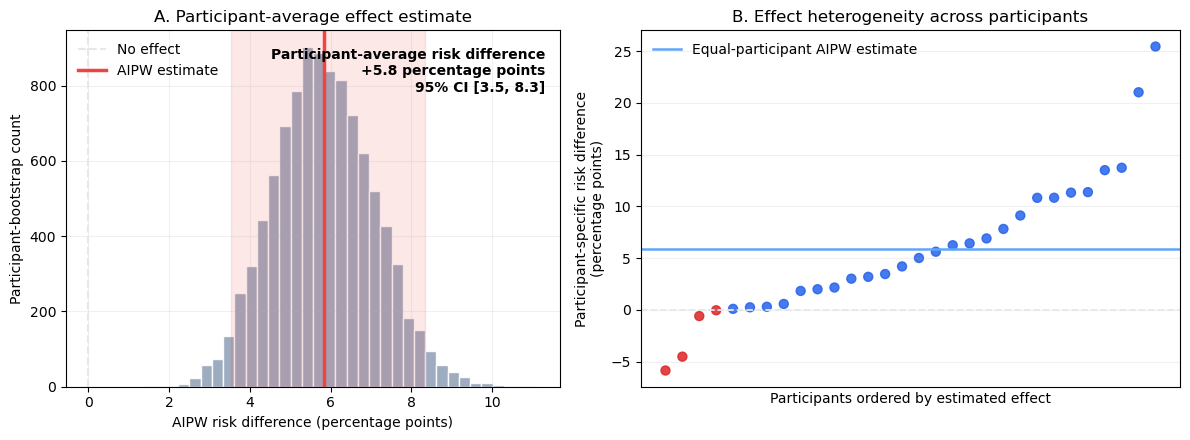

In [16]:
# Equal participant weighting: the original estimand
participant_effects = (
    causal_samples
    .assign(aipw_score=aipw_score)
    .groupby("participant_id", as_index=False)
    .agg(
        effect=("aipw_score", "mean"),
        observations=("aipw_score", "size"),
    )
)

effect_estimate = participant_effects["effect"].mean()

# Bootstrap the 30 participant-level effects
rng = np.random.default_rng(SEED)
effect_array = participant_effects["effect"].to_numpy()

bootstrap_effects = np.array([
    rng.choice(
        effect_array,
        size=len(effect_array),
        replace=True,
    ).mean()
    for _ in range(10000)
])

ci_low, ci_high = np.percentile(
    bootstrap_effects,
    [2.5, 97.5],
)

participant_effects = (
    participant_effects
    .sort_values("effect")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.5),
    gridspec_kw={"width_ratios": [1.1, 1.2]},
)

# A. Participant-level bootstrap
axes[0].hist(
    100 * bootstrap_effects,
    bins=35,
    color="#94a3b8",
    edgecolor="white",
    alpha=0.9,
)
axes[0].axvline(
    0,
    color="#e5e7eb",
    linestyle="--",
    linewidth=1.5,
    label="No effect",
)
axes[0].axvline(
    100 * effect_estimate,
    color="#ef4444",
    linewidth=2.5,
    label="AIPW estimate",
)
axes[0].axvspan(
    100 * ci_low,
    100 * ci_high,
    color="#ef4444",
    alpha=0.12,
)

axes[0].text(
    0.97, 0.95,
    f"Participant-average risk difference\n"
    f"{100 * effect_estimate:+.1f} percentage points\n"
    f"95% CI [{100 * ci_low:.1f}, {100 * ci_high:.1f}]",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    weight="bold",
)

axes[0].set(
    xlabel="AIPW risk difference (percentage points)",
    ylabel="Participant-bootstrap count",
    title="A. Participant-average effect estimate",
)
axes[0].legend(frameon=False, loc="upper left")

# B. Participant-specific estimates
point_colors = np.where(
    participant_effects["effect"].ge(0),
    "#2563eb",
    "#dc2626",
)

axes[1].scatter(
    np.arange(len(participant_effects)),
    100 * participant_effects["effect"],
    s=42,
    color=point_colors,
    alpha=0.85,
)
axes[1].axhline(
    0,
    color="#e5e7eb",
    linestyle="--",
    linewidth=1.3,
)
axes[1].axhline(
    100 * effect_estimate,
    color="#60a5fa",
    linewidth=1.8,
    label="Equal-participant AIPW estimate",
)

axes[1].set(
    xticks=[],
    xlabel="Participants ordered by estimated effect",
    ylabel="Participant-specific risk difference\n(percentage points)",
    title="B. Effect heterogeneity across participants",
)
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

**Positive Forward Direction, Variability and Possible Propagation Effect and Negative**

After adjustment, source-HFO times were followed by a spatially non-overlapping HFO approximately six percentage points more often than matched non-HFO times. The participant-level bootstrap interval excluded zero.

Most participant-specific estimates were positive, but the magnitude varied substantially across children. The result therefore supports a reproducible adjusted temporal association, while also indicating meaningful individual heterogeneity.

## 6. Stress-Testing the Directional Interpretation

I challenged the main result using a backward temporal placebo, a symmetric adjustment set, and source HFOs preceded by at least two seconds without another event.

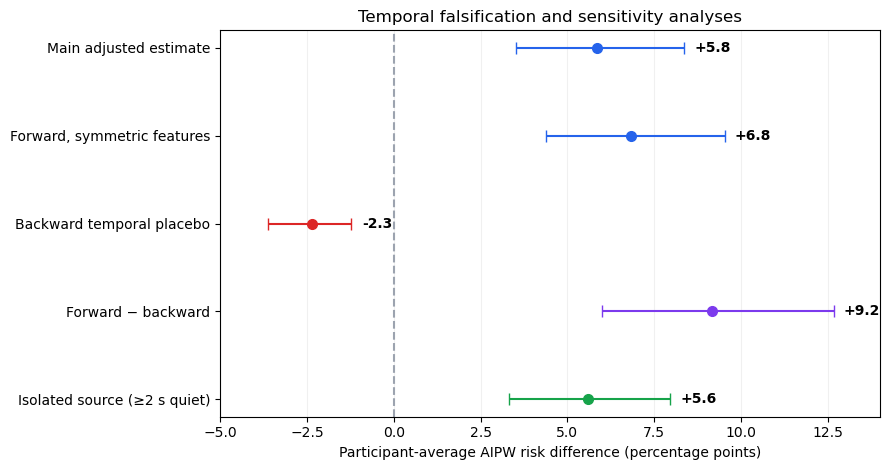

In [17]:
def participant_summary(score, data, seed):
    values = (
        pd.DataFrame({
            "participant_id": data["participant_id"].to_numpy(),
            "score": score,
        })
        .groupby("participant_id")["score"]
        .mean()
        .to_numpy()
    )

    rng = np.random.default_rng(seed)
    bootstrap = np.array([
        rng.choice(values, len(values), replace=True).mean()
        for _ in range(10000)
    ])

    return np.r_[
        values.mean(),
        np.percentile(bootstrap, [2.5, 97.5]),
    ]


def fit_aipw(data, outcome, features, seed):
    data = data.reset_index(drop=True)

    channel_features = pd.get_dummies(
        data["source_channel"],
        prefix="source",
        dtype=float,
    )

    X = np.column_stack([
        data[features].to_numpy(dtype=float),
        channel_features.to_numpy(dtype=float),
    ])
    T = data["treatment"].to_numpy(dtype=int)
    Y = data[outcome].to_numpy(dtype=int)
    groups = data["participant_id"].to_numpy()

    e = np.full(len(data), np.nan)
    mu1 = np.full(len(data), np.nan)
    mu0 = np.full(len(data), np.nan)

    for fold, (train, test) in enumerate(
        GroupKFold(5).split(X, Y, groups),
        start=1,
    ):
        e_model = make_model(seed + fold).fit(X[train], T[train])
        e[test] = e_model.predict_proba(X[test])[:, 1]

        treated = train[T[train] == 1]
        control = train[T[train] == 0]

        mu1[test] = (
            make_model(seed + 100 + fold)
            .fit(X[treated], Y[treated])
            .predict_proba(X[test])[:, 1]
        )
        mu0[test] = (
            make_model(seed + 200 + fold)
            .fit(X[control], Y[control])
            .predict_proba(X[test])[:, 1]
        )

    e = np.clip(e, 0.05, 0.95)

    score = (
        mu1 - mu0
        + T * (Y - mu1) / e
        - (1 - T) * (Y - mu0) / (1 - e)
    )

    return participant_summary(score, data, seed), score


# Exclude recent-history variables that overlap the backward outcome
direction_features = [
    "run",
    "time_fraction",
    "age",
    "sex_binary",
    "history_2_10s",
]

forward, forward_score = fit_aipw(
    causal_samples,
    "outcome",
    direction_features,
    SEED + 1000,
)

backward, backward_score = fit_aipw(
    causal_samples,
    "distant_HFO_before",
    direction_features,
    SEED + 2000,
)

directional_score = forward_score - backward_score
directional = participant_summary(
    directional_score,
    causal_samples,
    SEED + 3000,
)

# Require both source and matched-control times to be quiet for ≥2 s
quiet = causal_samples[
    [
        "history_25_100ms",
        "history_100_500ms",
        "history_500ms_2s",
        "distant_HFO_before",
    ]
].eq(0).all(axis=1)

quiet_pairs = quiet.groupby(causal_samples["pair_id"]).all()
isolated_samples = causal_samples.loc[
    causal_samples["pair_id"].isin(quiet_pairs[quiet_pairs].index)
].copy()

isolated, _ = fit_aipw(
    isolated_samples,
    "outcome",
    [
        "run",
        "time_fraction",
        "age",
        "sex_binary",
        "history_2_10s",
        "source_channel_history_10s",
    ],
    SEED + 4000,
)

results = pd.DataFrame(
    [
        ["Main adjusted estimate", effect_estimate, ci_low, ci_high],
        ["Forward, symmetric features", *forward],
        ["Backward temporal placebo", *backward],
        ["Forward − backward", *directional],
        ["Isolated source (≥2 s quiet)", *isolated],
    ],
    columns=["Analysis", "Effect", "CI_low", "CI_high"],
)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(results))
colors = ["#2563eb", "#2563eb", "#dc2626", "#7c3aed", "#16a34a"]

for i, row in results.iterrows():
    ax.errorbar(
        100 * row["Effect"],
        i,
        xerr=[[
            100 * (row["Effect"] - row["CI_low"])
        ], [
            100 * (row["CI_high"] - row["Effect"])
        ]],
        fmt="o",
        markersize=7,
        capsize=4,
        color=colors[i],
    )
    ax.text(
        100 * row["CI_high"] + 0.3,
        i,
        f"{100 * row['Effect']:+.1f}",
        va="center",
        weight="bold",
    )

ax.axvline(0, color="#9ca3af", linestyle="--")
ax.set(
    yticks=y,
    yticklabels=results["Analysis"],
    xlim=(-5, 14),
    xlabel="Participant-average AIPW risk difference (percentage points)",
    title="Temporal falsification and sensitivity analyses",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.18)

plt.tight_layout()
plt.show()

**Stable Forward Effect, Backward Effect Exists**

The forward association remained positive with symmetric adjustment and after restricting the analysis to isolated source events. However, the backward placebo was negative rather than null, indicating residual temporal selection or refractory dynamics.

The results therefore support a directional temporal asymmetry, but do not yet establish biological HFO propagation.

## 7. When Does the Directional Difference Appear?

If the association reflects short-lag transmission, it should be strongest immediately after the source HFO and weaken with increasing delay. I therefore estimated the effect in four mirrored time windows before and after each reference event.

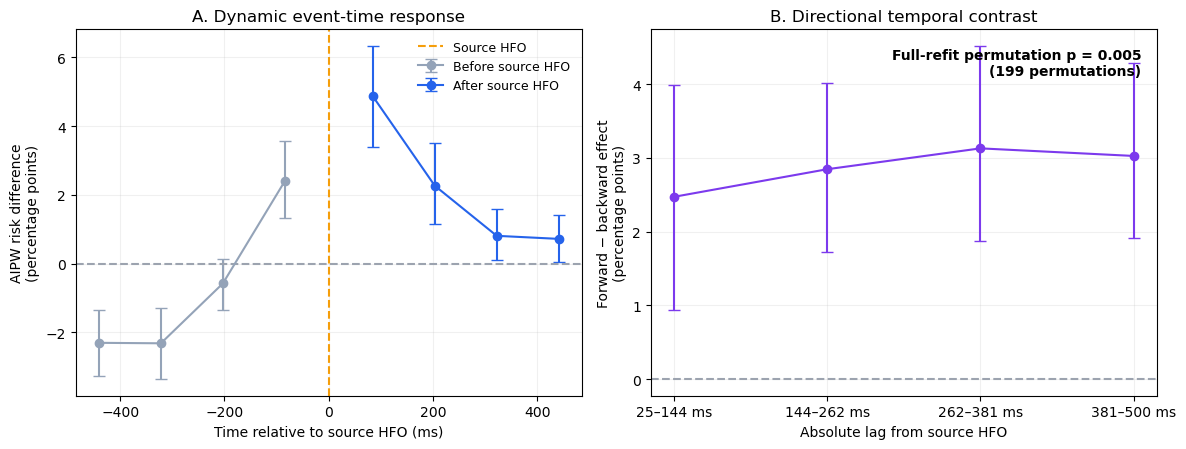

In [18]:
DERIV_ROOT = ROOT / "derivatives"

edges = np.linspace(0.025, 0.500, 5)
forward_windows = [
    (edges[i], edges[i + 1])
    for i in range(4)
]
backward_windows = [
    (-edges[i + 1], -edges[i])
    for i in range(4)
]


def spatially_separate(channel_a, channel_b):
    return set(str(channel_a).split("-")).isdisjoint(
        str(channel_b).split("-")
    )


def window_outcome(
    burst_times,
    burst_channels,
    reference_time,
    source_channel,
    window,
):
    left = np.searchsorted(
        burst_times,
        reference_time + window[0],
        side="left",
    )
    right = np.searchsorted(
        burst_times,
        reference_time + window[1],
        side="right",
    )

    return int(any(
        spatially_separate(source_channel, target)
        for targets in burst_channels[left:right]
        for target in targets
    ))


# Construct outcomes in four mirrored pre/post windows
dynamic_samples = causal_samples.copy()

for i in range(4):
    dynamic_samples[f"forward_bin_{i}"] = 0
    dynamic_samples[f"backward_bin_{i}"] = 0

for (participant, run), indices in dynamic_samples.groupby(
    ["participant_id", "run"]
).groups.items():

    stem = (
        f"{participant}_ses-01_task-hfo_"
        f"run-{int(run):02d}"
    )
    events_path = (
        DERIV_ROOT / participant / "ses-01" / "eeg"
        / f"{stem}_events.tsv"
    )
    channels_path = events_path.with_name(
        f"{stem}_channels.tsv"
    )

    events = pd.read_csv(events_path, sep="\t")
    events = events.loc[
        pd.to_numeric(
            events["EvPassRejection"],
            errors="coerce",
        ).eq(1)
    ].copy()

    event_sfreq = float(
        pd.read_csv(
            channels_path,
            sep="\t",
        )["sampling_frequency"].iloc[0]
    )

    events["burst_time"] = (
        pd.to_numeric(events["indStart"], errors="coerce")
        + pd.to_numeric(events["indStop"], errors="coerce")
    ) / (2 * event_sfreq)

    events = (
        events
        .dropna(subset=["burst_time", "strChannelName"])
        .sort_values("burst_time")
    )

    new_burst = np.r_[
        True,
        np.diff(events["burst_time"]) > 0.025,
    ]
    events["burst_id"] = np.cumsum(new_burst) - 1

    bursts = (
        events
        .groupby("burst_id")
        .agg(
            burst_time=("burst_time", "median"),
            channels=(
                "strChannelName",
                lambda x: tuple(sorted(set(x))),
            ),
        )
    )

    burst_times = bursts["burst_time"].to_numpy()
    burst_channels = bursts["channels"].tolist()

    for row_index in indices:
        reference_time = float(
            dynamic_samples.at[row_index, "reference_time"]
        )
        source_channel = dynamic_samples.at[
            row_index,
            "source_channel",
        ]

        for i, window in enumerate(forward_windows):
            dynamic_samples.at[
                row_index,
                f"forward_bin_{i}",
            ] = window_outcome(
                burst_times,
                burst_channels,
                reference_time,
                source_channel,
                window,
            )

        for i, window in enumerate(backward_windows):
            dynamic_samples.at[
                row_index,
                f"backward_bin_{i}",
            ] = window_outcome(
                burst_times,
                burst_channels,
                reference_time,
                source_channel,
                window,
            )


# Estimate each window using the same symmetric adjustment set
event_time_features = [
    "run",
    "time_fraction",
    "age",
    "sex_binary",
    "history_2_10s",
]

event_rows = []
window_scores = {}

for direction, windows, seed_offset in [
    ("Before source HFO", backward_windows, 5000),
    ("After source HFO", forward_windows, 6000),
]:
    prefix = "backward" if direction.startswith("Before") else "forward"

    for i, window in enumerate(windows):
        column = f"{prefix}_bin_{i}"

        estimate, score = fit_aipw(
            dynamic_samples,
            column,
            event_time_features,
            SEED + seed_offset + i,
        )
        window_scores[column] = score

        event_rows.append({
            "Direction": direction,
            "Midpoint": 500 * sum(window),
            "Effect": estimate[0],
            "CI_low": estimate[1],
            "CI_high": estimate[2],
        })

event_time_results = pd.DataFrame(event_rows)


# Compare each post-event window with its mirrored pre-event window
directional_rows = []

for i, window in enumerate(forward_windows):
    contrast = participant_summary(
        window_scores[f"forward_bin_{i}"]
        - window_scores[f"backward_bin_{i}"],
        dynamic_samples,
        SEED + 7000 + i,
    )

    directional_rows.append({
        "Lag": (
            f"{1000 * window[0]:.0f}–"
            f"{1000 * window[1]:.0f} ms"
        ),
        "Effect": contrast[0],
        "CI_low": contrast[1],
        "CI_high": contrast[2],
    })

directional_results = pd.DataFrame(directional_rows)

# Cached results from 199 full within-pair label permutations
permutation_null = pd.read_csv(
    ROOT / "full_dynamic_label_permutation_v1.csv"
)

observed_max = directional_results["Effect"].abs().max()
global_p = (
    1
    + permutation_null["max_absolute_effect"].ge(
        observed_max
    ).sum()
) / (len(permutation_null) + 1)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# A. Event-time response
for direction, color in [
    ("Before source HFO", "#94a3b8"),
    ("After source HFO", "#2563eb"),
]:
    plot_data = (
        event_time_results.loc[
            event_time_results["Direction"].eq(direction)
        ]
        .sort_values("Midpoint")
    )

    axes[0].errorbar(
        plot_data["Midpoint"],
        100 * plot_data["Effect"],
        yerr=[
            100 * (
                plot_data["Effect"]
                - plot_data["CI_low"]
            ),
            100 * (
                plot_data["CI_high"]
                - plot_data["Effect"]
            ),
        ],
        fmt="o-",
        capsize=4,
        color=color,
        label=direction,
    )

axes[0].axhline(0, color="#9ca3af", linestyle="--")
axes[0].axvline(
    0,
    color="#f59e0b",
    linestyle="--",
    label="Source HFO",
)
axes[0].set(
    xlabel="Time relative to source HFO (ms)",
    ylabel="AIPW risk difference\n(percentage points)",
    title="A. Dynamic event-time response",
)
axes[0].legend(frameon=False, fontsize=9)

# B. Mirrored directional contrasts
x = np.arange(4)

axes[1].errorbar(
    x,
    100 * directional_results["Effect"],
    yerr=[
        100 * (
            directional_results["Effect"]
            - directional_results["CI_low"]
        ),
        100 * (
            directional_results["CI_high"]
            - directional_results["Effect"]
        ),
    ],
    fmt="o-",
    capsize=4,
    color="#7c3aed",
)

axes[1].axhline(0, color="#9ca3af", linestyle="--")
axes[1].text(
    0.97,
    0.95,
    f"Full-refit permutation p = {global_p:.3f}\n"
    f"({len(permutation_null)} permutations)",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    weight="bold",
)
axes[1].set(
    xticks=x,
    xticklabels=directional_results["Lag"],
    xlabel="Absolute lag from source HFO",
    ylabel="Forward − backward effect\n(percentage points)",
    title="B. Directional temporal contrast",
)

for ax in axes:
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()

**Time Pattern Supports Propagation, Backward Effect Exists**

The largest increase occurred within 25–144 ms after the source HFO and weakened at longer delays. Each post-event window also exceeded its mirrored pre-event window; this directional curve was unlikely under full within-pair label permutation (*p* = 0.005).

However, the pre-event curve was not flat and began rising shortly before the source event. The pattern is therefore compatible with short-lag propagation, but residual burst structure or event-selection effects remain plausible.

## 8. Limitations and Future Work

### Limitations

1. **Dataset mismatch:** only short N3 segments from children with epilepsy—not full-night sleep or the target neurodevelopmental population.
2. **Residual confounding:** the non-null backward placebo suggests remaining temporal selection or shared excitability.
3. **Limited spatial evidence:** non-overlapping scalp channels do not establish anatomical propagation or exclude volume conduction.

### Future Work

1. **Use richer PhD data:** full-night paediatric EEG, expert annotations, multiple sleep stages and neurodevelopmental measures.
2. **Strengthen causal identification:** hierarchical temporal models, negative controls and sensitivity analyses across participants.
3. **Address the clinical question:** link interpretable sleep and HFO dynamics to cognition, behaviour and equitable diagnosis.
